In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("shoe_sales.csv")
df.head()

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
1,9/1/2023,Adidas,14.0
2,9/2/2023,Nike,21.0
3,9/2/2023,Adidas,12.0
4,9/3/2023,Nike,18.0


In [10]:
df.shape

(60, 3)

In [11]:
df.describe()

,sold_qty
count,58.000000
mean,27.482759
std,88.519844
min,7.000000
25%,12.250000
50%,16.000000
75%,19.750000
max,689.000000


In [12]:
df[df.sold_qty < 12.25].shape

(15, 3)

### 1) Nike Analysis

In [13]:
df_nike = df[df.brand == "Nike"]
df_nike.shape

(30, 3)

In [14]:
df_nike.describe()

,sold_qty
count,28.000000
mean,19.642857
std,3.117624
min,14.000000
25%,17.000000
50%,19.500000
75%,22.000000
max,25.000000


In [29]:
value = round(df_nike.sold_qty.median())
value

20

In [27]:
df_nike.sold_qty.sum()

np.float64(550.0)

* So here we can see that sold quantity of nike shoes is between 14 to 25 in this month
* And on avg we have sold 20 nike shoes daily
* And Total 550 Nike shoes sold this month

- Now let's check if any null values avail

In [28]:
df_nike[df_nike.sold_qty.isnull()]

,date,brand,sold_qty
32,9/17/2023,Nike,NaN
48,9/25/2023,Nike,NaN


In [30]:
df_nike.sold_qty.fillna(value,inplace = True)

C:\Users\ANSHH\AppData\Local\Temp\ipykernel_12832\2834855161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nike.sold_qty.fillna(value,inplace = True)


In [31]:
df_nike[df_nike.sold_qty.isnull()]

,date,brand,sold_qty


In [33]:
df_nike.loc[[32,48]]

,date,brand,sold_qty
32,9/17/2023,Nike,20.0
48,9/25/2023,Nike,20.0


* So this is how we handle null vales by replacing it with median or mean

### 2) Adidas Analysis

In [19]:
df_adidas = df[df.brand == "Adidas"]
df_adidas.shape

(30, 3)

In [20]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [34]:
df_adidas.sold_qty.quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

* It says that 95% Values are less than 18.55 

In [35]:
df_adidas[df_adidas.sold_qty > 18.55]

,date,brand,sold_qty
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


* So it's visible that 689 is a outlier
* So we can remove that or replace that with the median value (Here we can't use mean coz it's value is influenced by the outlier )

In [37]:
value = round(df_adidas.sold_qty.median())
value

12

In [53]:
def plot_qty():
    plt.figure(figsize = (15,6))
    plt.plot(df_adidas.date,df_adidas.sold_qty, marker = "o", label = 'Adidas', color = 'blue')
    plt.plot(df_nike.date,df_nike.sold_qty, marker = "o", label = 'Nike', color = 'red')
    plt.xlabel("Date")
    plt.ylabel("Sold")
    plt.title("Shoes Sold Data")
    plt.xticks(rotation = 45)
    plt.legend()
    plt.grid(True, which = "both",linestyle = '--', linewidth = 0.5)

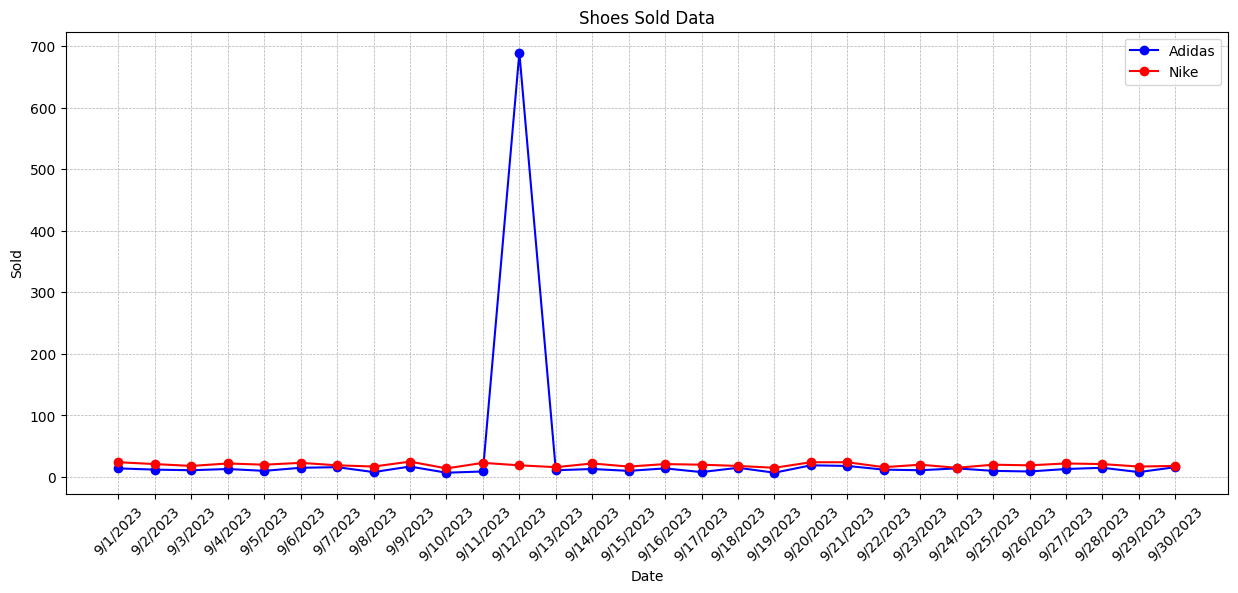

In [54]:
plot_qty()

In [55]:
df_adidas.sold_qty.replace(689,value, inplace = True)

C:\Users\ANSHH\AppData\Local\Temp\ipykernel_12832\2993201483.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adidas.sold_qty.replace(689,value, inplace = True)
C:\Users\ANSHH\AppData\Local\Temp\ipykernel_12832\2993201483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adidas.sold_qty.replace(689,value, inplace = True)


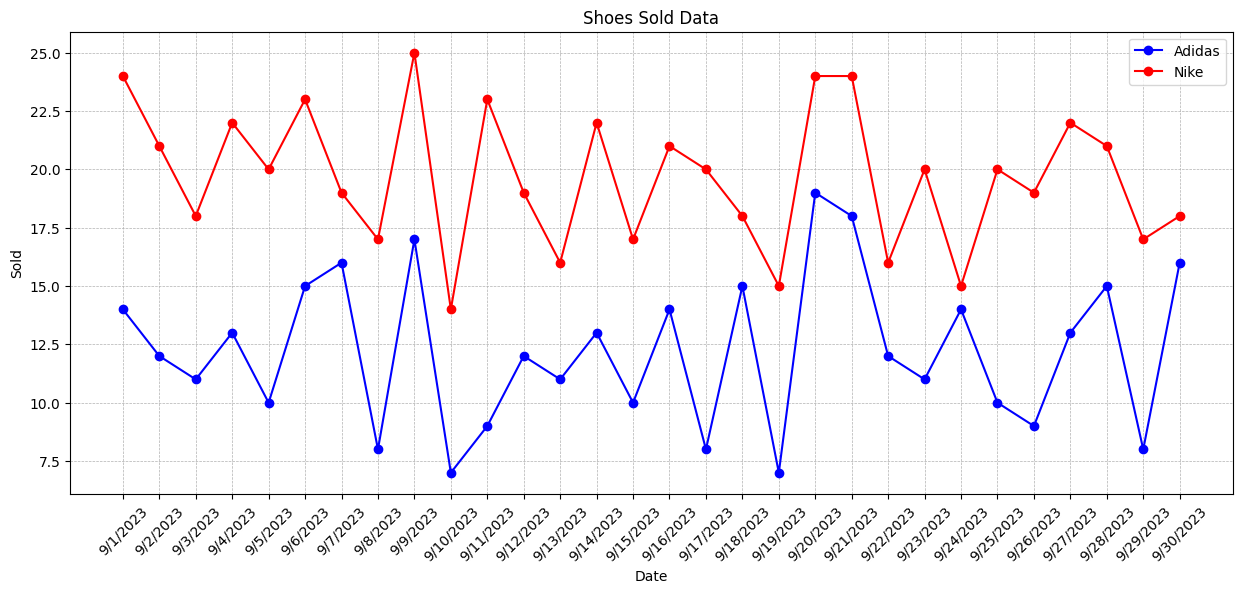

In [56]:
plot_qty()

* This is how outlier gets removed

In [57]:
df_adidas.sold_qty.sum()

np.float64(367.0)

* This is correct amount of total adidas sold now

In [58]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,12.233333
std,3.287210
min,7.000000
25%,10.000000
50%,12.000000
75%,14.750000
max,19.000000
